In [1]:
import os
os.environ["XDG_CACHE_HOME"] = "/ceph/hpc/home/ciangottinid/.cache"
import skimage

In [11]:
from tqdm import tqdm
import torch
import numpy as np
import xarray as xr
from skimage.metrics import structural_similarity as ssim
from scipy.stats import entropy
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings("ignore")

from Fires._utilities.metrics import WeightedBCE_L1Loss
from Fires._utilities.utils_mlflow import load_model_from_mlflow

from Fires._utilities.utils_inference import plot_accumulated_weighted_map,compute_values,plot_burned_area_difference_map,compute_aggregated_mape_smape,load_input_data, create_data_loader, process_and_plot_data, get_prov_image

In [3]:
run_name=input()
registered_model = load_model_from_mlflow(run_name, provenance=True)
registered_model 

 lastone


Data from MLFlow downloaded in: /jupyter-workspace/persistent-storage/ML4Fires/MLFLOW/lastone


UnetPlusPlus(
  (activation): Sigmoid()
  (pool_2x2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (pool_3x3): MaxPool2d(kernel_size=(3, 3), stride=(3, 3), padding=0, dilation=1, ceil_mode=False)
  (up_2x2): Upsample(scale_factor=(2.0, 2.0), mode='bilinear')
  (up_3x3): Upsample(scale_factor=(3.0, 3.0), mode='bilinear')
  (conv0_0): VGGBlock(
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv1_0): VGGBlock(
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Co

In [4]:
# define path to complete dataset
data_path = "/ceph/hpc/home/ciangottinid/ML4Fires/data/ML4Fires_copy/data_100km.zarr"

input_data = load_input_data(data_path, '2019', '2020')
input_data

['lai', 'rel_hum', 't2m_min', 'tp', 'lsm'] 
 ['fcci_ba']
(180, 360)


<xarray.Dataset> Size: 167MB
Dimensions:    (time: 92, latitude: 180, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
  * time       (time) datetime64[ns] 736B 2019-01-01 2019-01-09 ... 2020-12-26
Data variables:
    lai        (time, latitude, longitude) float32 24MB nan nan nan ... nan nan
    rel_hum    (time, latitude, longitude) float32 24MB 89.11 89.19 ... 61.39
    t2m_min    (time, latitude, longitude) float32 24MB 246.2 246.2 ... 242.5
    tp         (time, latitude, longitude) float32 24MB 1.802 1.802 ... 0.3219
    lsm        (time, latitude, longitude) float32 24MB 0.0 0.0 0.0 ... 1.0 1.0
    fcci_ba    (time, latitude, longitude) float64 48MB nan nan nan ... 0.0 0.0
Attributes:
    crs:          EPSG:4326
    description:  The SeasFire Cube is a scientific datacube for seasonal fir...
    title:        SeasFire Cube: A Global Dataset for Seasonal Fire Modeling ...

In [5]:
torch_data_loader = create_data_loader(data_path, run_name)

In [6]:
preds = []
with torch.no_grad():
	for data, _ in tqdm(torch_data_loader):
		prediction = registered_model(data.to('cuda:0'))
		prediction_cpu = prediction.cpu().numpy()
		preds.append(prediction_cpu)
preds_array = np.vstack(preds)

100%|██████████| 92/92 [00:02<00:00, 34.02it/s]


Is DataArray - AVG: (180, 360) STD: (180, 360)
 Mean of data: (180, 360)
 Max: 5135.48 	 Min: 0.0
 Lats Max: 1027.5 	 Lons Max: 539.6
 Mean of data: (180, 360)
 Max: 13253.32 	 Min: 0.0
 Lats Max: 1883.89 	 Lons Max: 1051.82


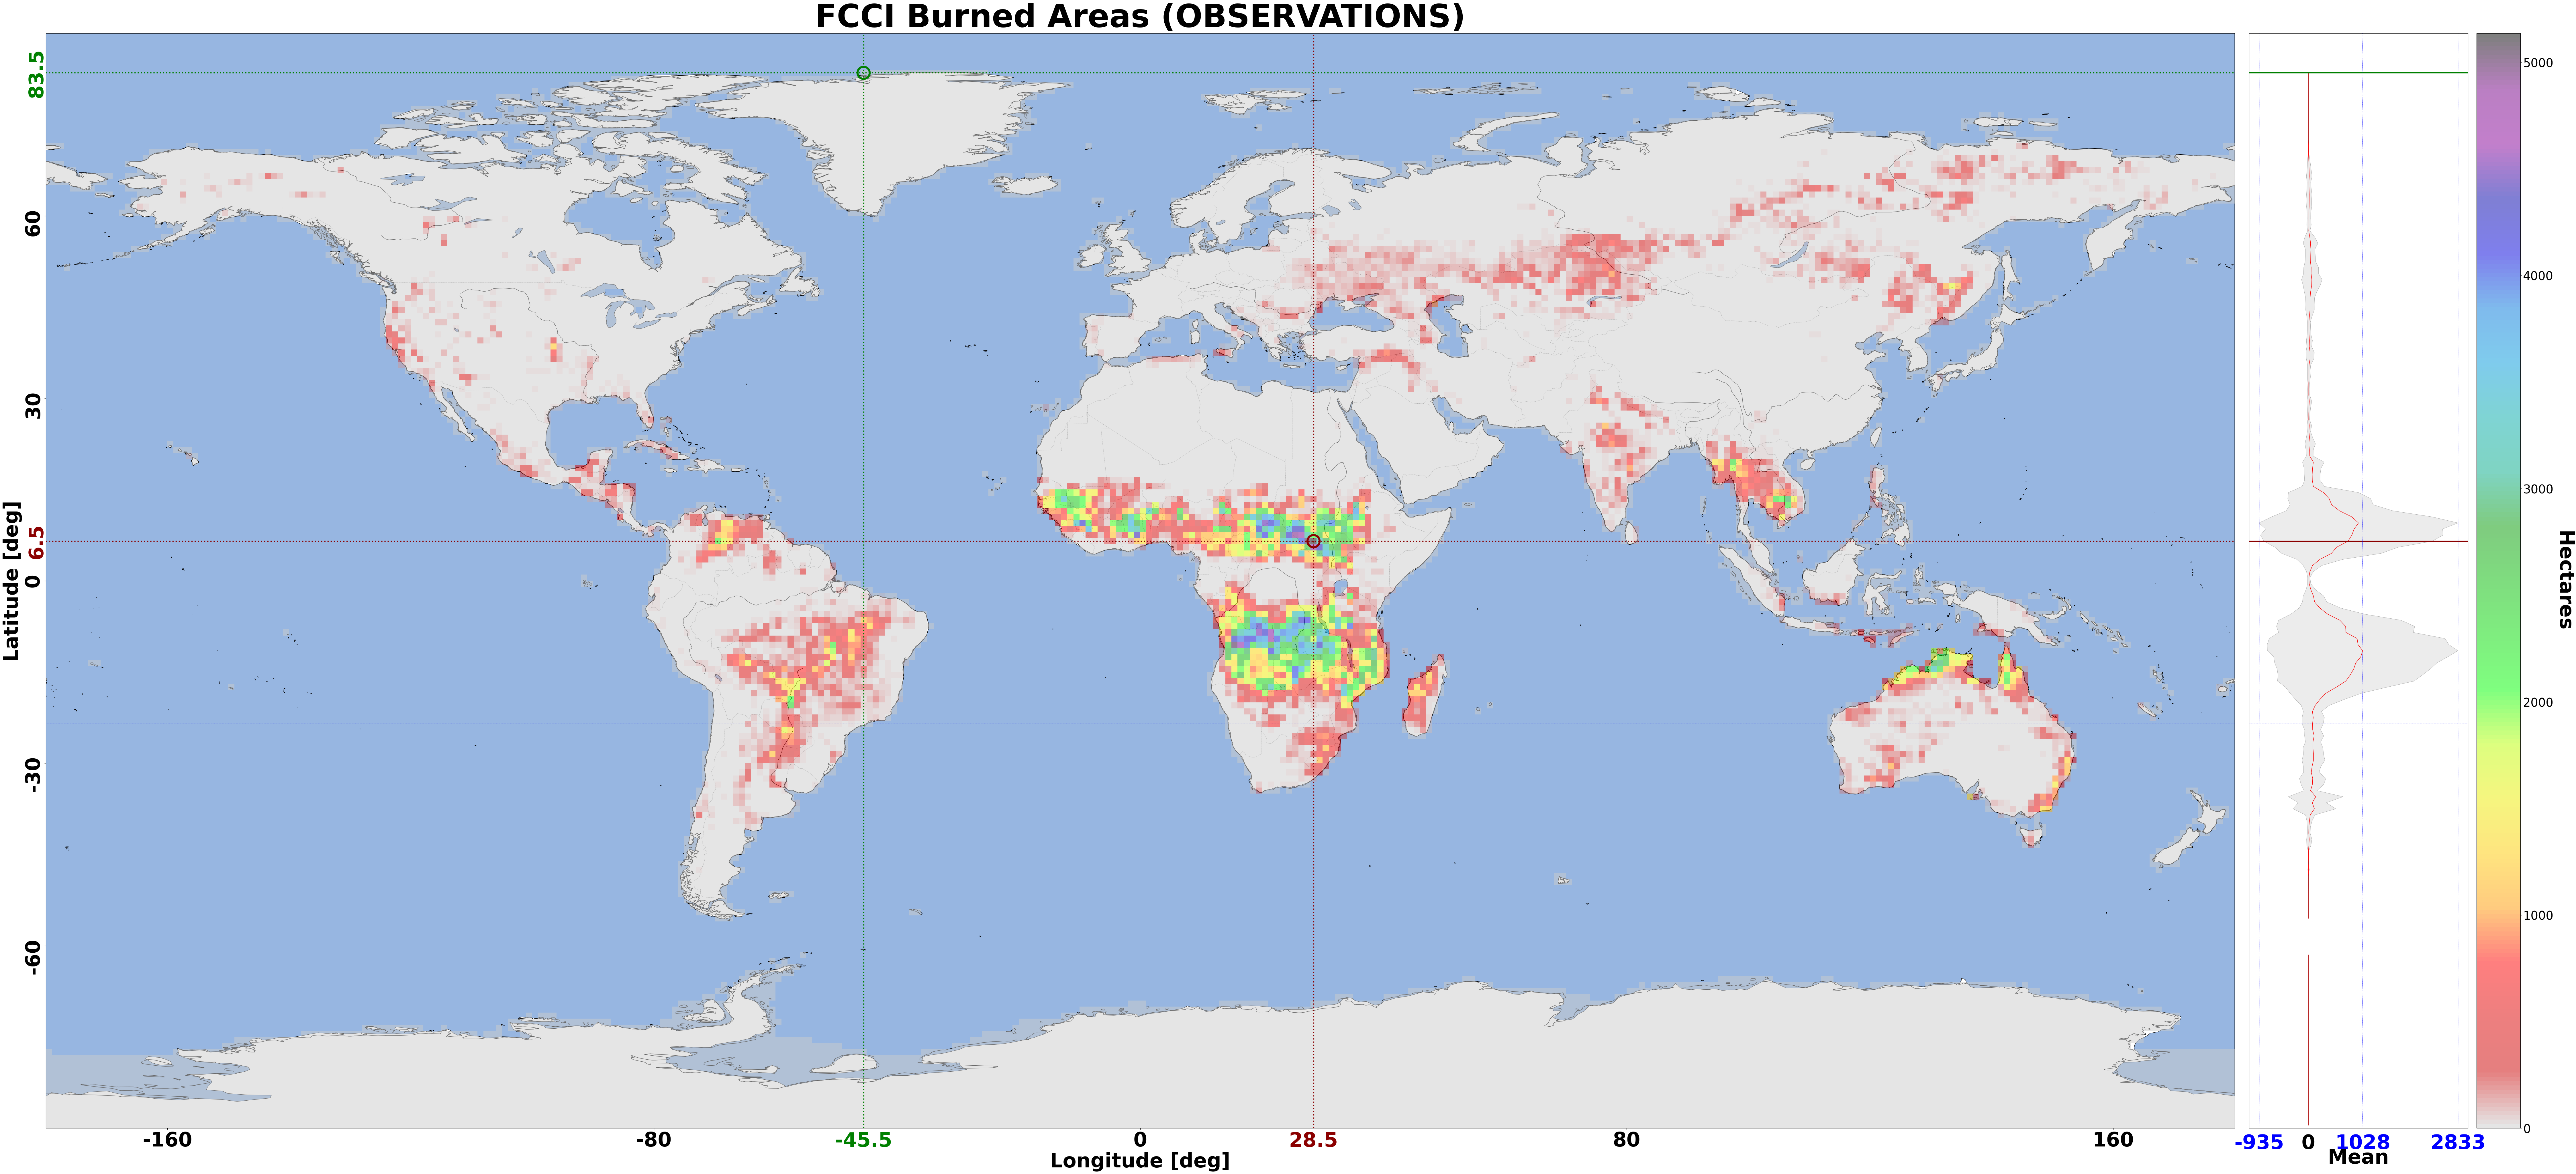

In [16]:
process_and_plot_data(
	data=input_data.fcci_ba,
	label='FCCI Burned Areas',
	lats=input_data.latitude.values,
	lons=input_data.longitude.values,
	model_name="Observations"
)

NOT DataArray - AVG: (180, 360) STD: (180, 360)
 Mean of data: (180, 360)
 Max: 5644.509765625 	 Min: 0.0
 Lats Max: 1013.97998046875 	 Lons Max: 583.719970703125
 Mean of data: (180, 360)
 Max: 12181.0400390625 	 Min: 0.0
 Lats Max: 1920.52001953125 	 Lons Max: 1009.3300170898438


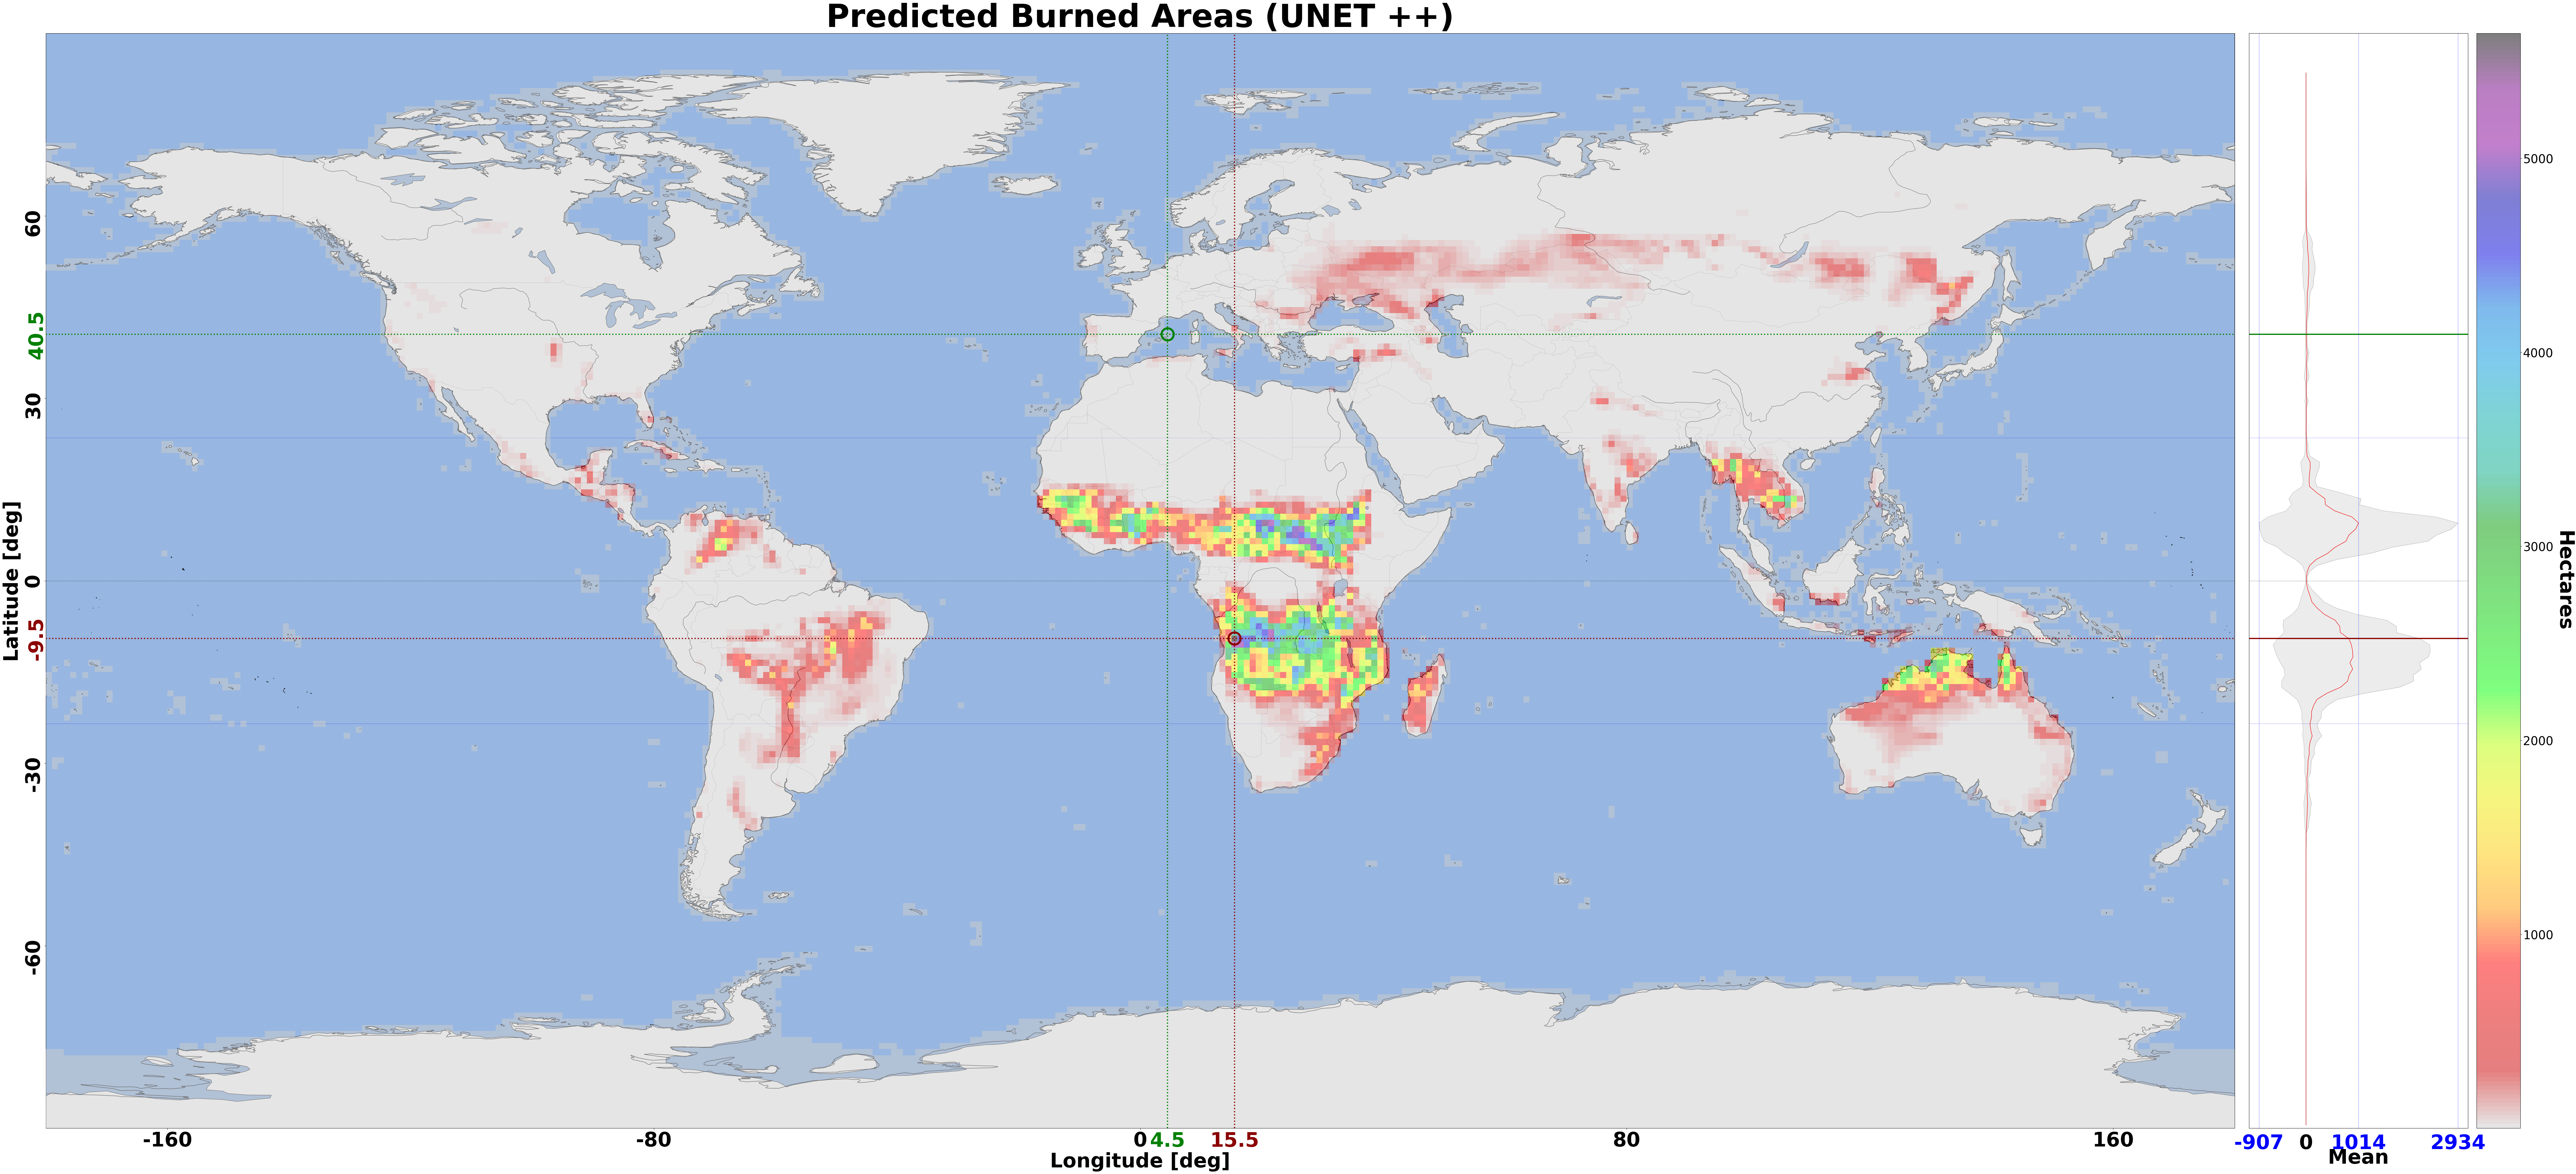

In [17]:
process_and_plot_data(
	data=preds_array,
	label='Predicted Burned Areas',
	lats=input_data.latitude.values,
	lons=input_data.longitude.values,
	model_name="Unet ++"
)

In [7]:
# (lastone,B=1,epoch=75, WeightedBCE_L1Loss)
metrics = compute_values(input_data, preds_array)
print(metrics)  

{'MAE': 0.00011754598381230608, 'SSIM': 0.9540847582051653}


In [8]:
input_tensor = torch.tensor(input_data["fcci_ba"].values, dtype=torch.float32)
preds_tensor = torch.tensor(preds_array, dtype=torch.float32)

    # Ensure preds_tensor has the correct shape by squeezing singleton dimension
preds_tensor = preds_tensor.squeeze(1)  # Removes the extra dimension

    # Create a mask for non-NaN values in fcci_ba
nan_mask = ~torch.isnan(input_tensor)  # True for valid values, False for NaNs

    # Apply the mask to remove NaN locations from both input and predictions
input_tensor = input_tensor[nan_mask]
preds_tensor = preds_tensor[nan_mask]
mape_val, smape_val = compute_aggregated_mape_smape(input_tensor, preds_tensor)

print("\n📊 Aggregated Performance Metrics (Summed over Time):")
print(f"✅ MAPE (%):  {mape_val:.4f}")
print(f"✅ sMAPE (%): {smape_val:.4f}")


📊 Aggregated Performance Metrics (Summed over Time):
✅ MAPE (%):  3.8062
✅ sMAPE (%): 3.7351


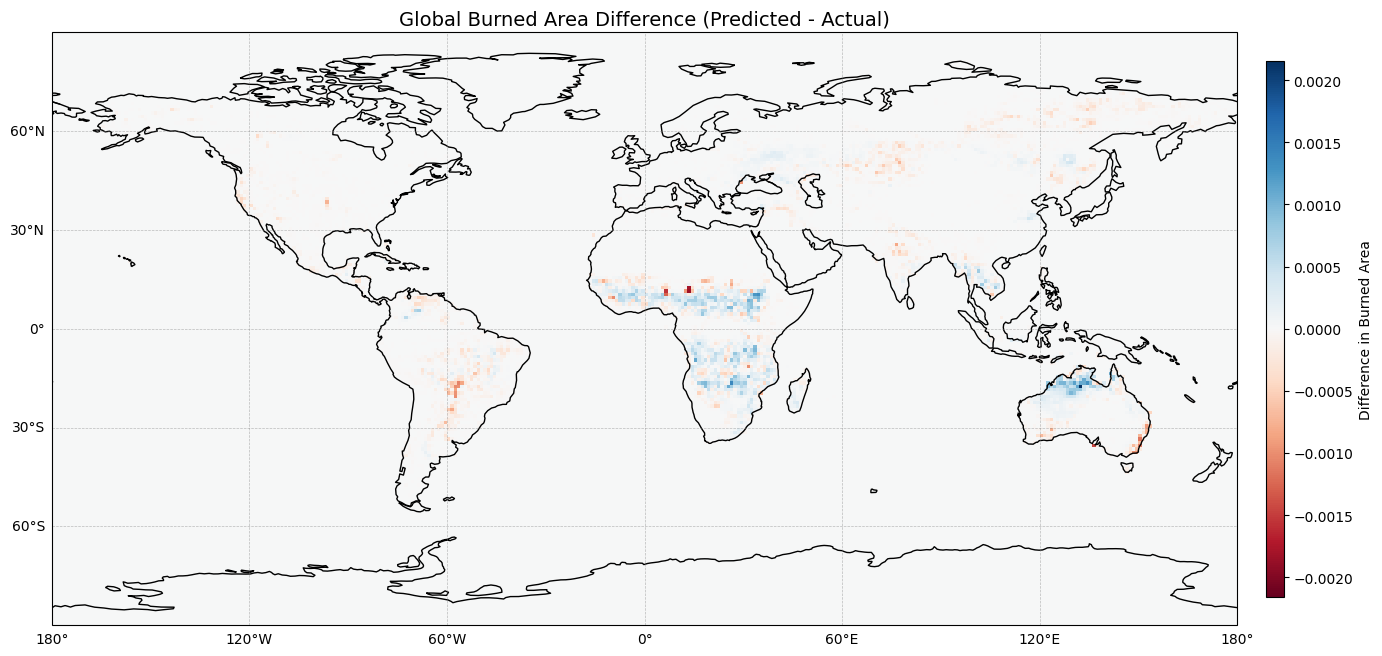

In [9]:
plot_burned_area_difference_map(input_data, preds_array)

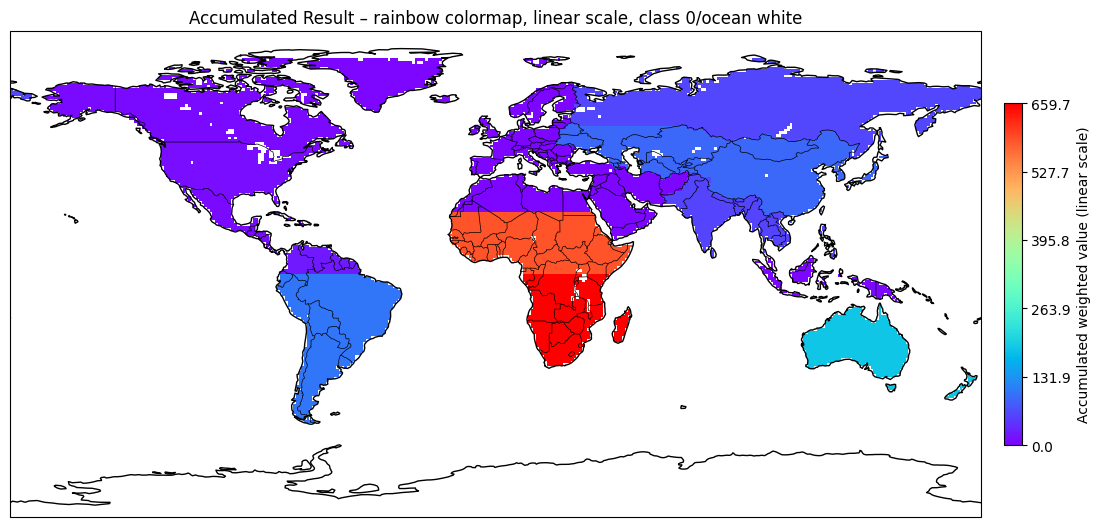

In [12]:
mask_path = "/ceph/hpc/home/ciangottinid/ML4Fires/mask.nc"
plot_accumulated_weighted_map(data_path, mask_path)